# Clarification selection

**Recipe 11** · Level 2 (Easy) · Decision type: `Choice`

Select a useful follow-up question from a predefined catalog when a task description omits information needed for the next step.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A clarification-selection assistant for short task requests. Jev reads one task description and picks exactly one of seven options: six fixed catalog entries, each one specific follow-up question (`ask_deadline`, `ask_recipient`, `ask_scope`, `ask_format`, `ask_budget`, `ask_access_level`), or the explicit fallback `no_clarification_needed`, which the use case names for a task that already states everything its next step needs. Python owns everything else: the state Jev sees (the task description, and nothing else), the stored question text for each catalog entry (the model never writes it, only picks the identifier), and the rule that asks a confident real match's stored question, accepts `no_clarification_needed` as a final "nothing to ask" result whatever its confidence, and sends anything else uncertain to an explicit `review` outcome. The 40 stored answers in `fixtures/` are all synthetic (none came from a real call). By the end you will have looked at individual typed answers across the range of confidence this recipe covers, seen the rule that acts on them, and run an evaluation that reports the accuracy of the selected follow-up, the accuracy of the ask-or-proceed decision underneath it, and a coverage, accuracy and risk computed from what the rule itself did.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number. In a synthetic run a validation number
# carries BOTH labels, {selection}{check}: it is a selection step, and that selection step is
# itself only a pipeline check, not a Jev result.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# task that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "clarification"
        ]
    return answered[example.id]


run_header(
    11,
    "Clarification selection",
    backend=backend,
    n_examples=len(scored),
)

Recipe 11: Clarification selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `task_id` and `text`, the task description. `build_state` passes on the task text only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its task.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-ambiguous"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "task_id": "TK301",
  "text": "Set up a shared project tracker for the ops team."
}
Jev sees:
{
  "task": "Set up a shared project tracker for the ops team."
}


## The questions

There is one question, and it asks one thing: which single follow-up question, if any, should be asked before this task moves to its next step? A `Choice` fits because the outcomes are exclusive and Jev should commit to exactly one ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no inherent order). Six of the seven options are the catalog's follow-up questions; Python builds the option set and holds the stored question text for each one, and returns that text unchanged for a confident match -- the model never writes the question itself ([S06](https://docs.typesafe.ai/cookbooks) covers this shape, selecting from a fixed candidate set, as a worked pattern). The seventh, `no_clarification_needed`, is the explicit fallback the use case names for a task that does not need any of the six. Each option's description says what belongs to it and, for the two pairs that are easiest to confuse -- a stated recipient against a stated, but narrower, access list; a stated scope against a stated, but undetermined, format -- what belongs to the other option instead.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): with seven options, 0 when the top option holds no more than a seventh of the probability, 1 when one option holds all of it. It depends only on that top probability, not on how the rest is spread across the other six, so a low confidence here does not mean the task is unreadable; it means the top option did not pull far ahead of an even seventh, which, for a task that could plausibly be missing either of two things, is often the honest shape for the probabilities to take.

[S04](https://docs.typesafe.ai/concepts/how-to-build-with-system-one) frames this kind of decision as one narrow judgment embedded in code that keeps control flow: Jev picks an option, and Python (`select_followup` in `helpers.py`, below) decides what that option is allowed to do -- ask the stored question, accept `no_clarification_needed` as a final result, or hold the answer back for review.

In [3]:
clarification = questions["clarification"]
print(clarification.instructions)
for name, description in clarification.criteria.items():
    print(f"  {name:24s} {description}")

Which single follow-up question, if any, should be asked before this task description moves to the next step?
  ask_deadline             The task asks for something to be prepared or delivered but never says, in any form, when it is needed: no date, no day of the week, no 'by end of day/week', no event it must be ready before. Pick this only when timing is the one thing missing; a task that already gives a date or a relative deadline does not need this question, even when other details are also missing.
  ask_recipient            The task asks for something to be produced but never says who should receive it or who it is for: no name, team, role, or 'send to' instruction. A task that already names who gets the result, even only by role ('the finance team', 'my manager'), does not need this question; naming the recipient is not the same as saying who besides the requester may edit a shared item once it exists, which belongs to ask_access_level instead.
  ask_scope                The tas

## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a task that could plausibly need `ask_access_level` or `ask_deadline`, a task that already states everything its next step needs, and a task whose stored answer is simply wrong -- a real catalog entry, confidently enough to matter, but not the one the task is actually missing. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call. These three come from the `demo` and `validation` splits only; `test` is reported once, after every choice below is frozen, not peeked at here.

Choice: ask_access_level (confidence 0.30)
  ask_access_level         0.40  ########
  ask_deadline             0.33  #######
  ask_recipient            0.05  #
  ask_scope                0.05  #
  ask_format               0.05  #
  ask_budget               0.05  #
  no_clarification_needed  0.05  #
Provenance: synthetic


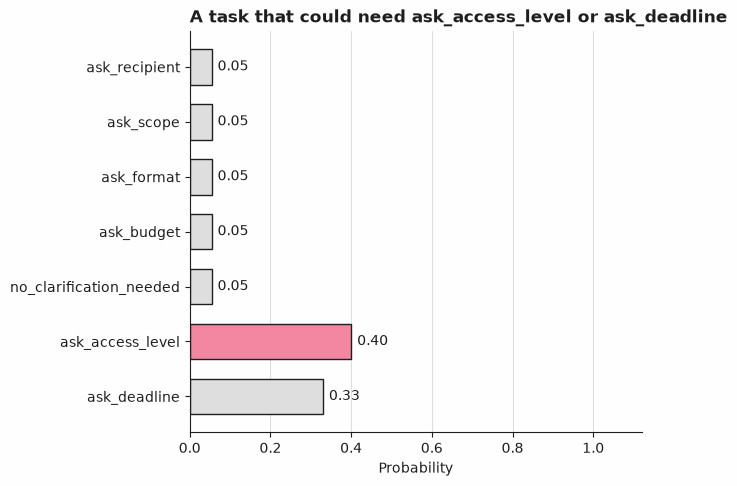

In [4]:
ambiguous_example = demo["d01-ambiguous"]
ambiguous_answer = decide(ambiguous_example)
show_answer(ambiguous_answer)
plot_answer_probabilities(
    ambiguous_answer, title="A task that could need ask_access_level or ask_deadline"
)

"Set up a shared project tracker for the ops team" names who it is for but says nothing about who besides the requester may edit the shared tracker once it exists, or when it is needed, so the stored answer puts `ask_access_level` only just ahead of `ask_deadline`, 0.40 against 0.33, for a `confidence` of 0.30: `(0.40 - 1/7) / (6/7)`. This row is a `demo` example and carries no **gold label** -- the correct option, decided in advance from the rule each option's description states, not from the model -- at all (no `demo` example in this recipe does), so there is nothing to score it against here; its purpose is to show the probabilities, not to be marked right or wrong. A reader could reasonably read this task as missing a deadline instead, which is exactly why the probabilities are this close rather than confidently one-sided.

In [5]:
proceed_example = demo["d02-confident-none"]
proceed_answer = decide(proceed_example)
show_answer(proceed_answer)

Choice: no_clarification_needed (confidence 0.77)
  no_clarification_needed  0.80  ################
  ask_deadline             0.03  #
  ask_recipient            0.03  #
  ask_scope                0.03  #
  ask_format               0.03  #
  ask_budget               0.03  #
  ask_access_level         0.03  #
Provenance: synthetic


"Export last week's refund requests as a spreadsheet for the finance team by noon tomorrow" already states the deliverable's scope (last week's refund requests), format (spreadsheet), recipient (the finance team) and deadline (noon tomorrow), and involves no budget or shared access, so nothing in the catalog applies. The stored answer agrees clearly: `no_clarification_needed` at 0.77 confidence. What Python does with this answer, whatever its confidence, matters more than the number itself: `select_followup`, below, accepts `no_clarification_needed` as a final result without checking confidence at all, because the option itself already says nothing needs to be asked -- there is no stored question a confidence check could protect here.

In [6]:
wrong_example = next(e for e in examples if e.id == "v08-scope-wrong")
wrong_answer = decide(wrong_example)
print(wrong_example.fields["text"])
show_answer(wrong_answer)

Put together a report on support tickets for the ops lead, due next week.
Choice: ask_format (confidence 0.30)
  ask_format               0.40  ########
  ask_scope                0.30  ######
  ask_deadline             0.06  #
  ask_recipient            0.06  #
  ask_budget               0.06  #
  ask_access_level         0.06  #
  no_clarification_needed  0.06  #
Provenance: synthetic


The gold label here is `ask_scope`: "a report on support tickets" already says the deliverable is a report (its format is settled), but never says which tickets or what time period, which is exactly what `ask_scope` is for. The stored answer gets this wrong: `ask_format` at 0.40 against `ask_scope`'s 0.30, a `confidence` of 0.30. This is the one wrong answer this recipe places in `validation` itself, on purpose: without it, every real-catalog answer in `validation` would be correct, and the confidence gate chosen two cells below would have nothing to cut on (it would come back as whatever the lowest observed confidence happens to be, whatever accuracy target is asked for). With it, the gate has a real wrong answer to exclude, and -- as the next section shows -- it does exclude this one.

## Python's part

Jev supplies the judgment; what happens with it is code. `select_followup` in `helpers.py` asks the stored catalog question for a confident real match, accepts `no_clarification_needed` as a final, un-gated result whatever its confidence (the issue's build note: options come from a predefined catalog plus `no_clarification_needed`, and Python decides between asking and proceeding -- the model does not write the question; `no_clarification_needed` has no stored question a confidence check could protect), and sends anything else below the gate to an explicit `review` outcome instead of asking a possibly wrong question. Accepting a low-confidence `no_clarification_needed` as final triggers no side effect in this recipe: Python only returns a "proceed, nothing to ask" result, never a simulated action such as dispatching the task onward. Here that means a wrong one costs this pipeline check some accuracy and nothing else -- no queue, no routing, no action is taken on it -- but it is exactly the kind of mistake `risk`, in the evaluation below, is counting, and in a real pipeline the cost would be the task moving on to its next step without the information it actually needed. `t12-budget-wrong`, below, is exactly this case. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, for a confident and a low-confidence answer of every one of the six catalog questions, for `no_clarification_needed` at both a high and a low confidence, and for an option outside the catalog entirely (a defensive check: the backend also rejects foreign options, but the rule does not trust that silently), so a rule that quietly exempted one catalog entry from the gate, or started gating `no_clarification_needed` on confidence after all, would fail it.

The one threshold this recipe chooses is a **confidence gate**: a cut-off on `confidence` below which an answer is sent to `review` instead of being acted on. It is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest confidence gate whose answered subset is perfectly accurate, over the `validation` tasks Jev actually matched to a real catalog entry (the ones it called `no_clarification_needed` are excluded from this selection on purpose -- `select_followup` never applies the gate to them, so feeding their confidence into the same selection would tune a gate the rule does not have). `v08-scope-wrong` above is the one wrong answer in that pool; the frozen gate is the lowest cut that excludes it. Applying that frozen gate to the three answers shown above, plus one clearly `ask_deadline` task for contrast, shows all three outcomes the rule can produce -- including, for the first time, a task that is sent to `review` -- and what Python returns for each: the stored question text for a confident match, and `None` for `no_clarification_needed` and `review` alike, since neither of those hands back a question.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]

# Only the tasks Jev actually matched to a real catalog entry go into the confidence-gate
# selection: a no_clarification_needed answer is never gated on confidence, so its confidence
# has no business tuning the gate.
real_match = [
    (a.choice == g, a.confidence)
    for a, g in zip(val_answers, val_gold, strict=True)
    if a.choice != helpers.NO_CLARIFICATION_NEEDED
]
real_correct = [correct for correct, _ in real_match]
real_confidence = [conf for _, conf in real_match]
threshold = select_confidence_threshold(real_correct, real_confidence, target_accuracy=1.0)
print(
    f"chosen confidence gate, frozen from here on: {threshold:.4f} "
    f"(over {len(real_match)} real-catalog matches in validation, 1 of them wrong){selection}{check}"
)

confident_example = next(e for e in val_examples if e.id == "v01-deadline-slidedeck")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (ambiguous_example, ambiguous_answer),
    (proceed_example, proceed_answer),
    (wrong_example, wrong_answer),
    (confident_example, confident_answer),
):
    result = helpers.select_followup(shown_example.fields["task_id"], shown_answer, threshold)
    print(
        f"{result.task_id}: {shown_answer.choice} at confidence "
        f"{shown_answer.confidence:.2f} -> {result.outcome} ({result.reason})"
    )
    print(f"  question returned to the requester: {result.question!r}")

chosen confidence gate, frozen from here on: 0.3350 (over 16 real-catalog matches in validation, 1 of them wrong) (a selection step, not a reported result) (a pipeline check, not a Jev result)
TK301: ask_access_level at confidence 0.30 -> review (confidence below the threshold)
  question returned to the requester: None
TK302: no_clarification_needed at confidence 0.77 -> proceed (the task already states everything)
  question returned to the requester: None
TK108: ask_format at confidence 0.30 -> review (confidence below the threshold)
  question returned to the requester: None
TK101: ask_deadline at confidence 0.82 -> ask (confident match)
  question returned to the requester: 'By when do you need this finished?'


## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.select_followup` is applied to every example in `validation` and in `test`, and the outcome counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports the **accuracy of the selected follow-up**: the fraction of tasks where Jev's single most probable option -- its raw `choice`, before `select_followup` does anything with it -- equals the gold label, over all seven options at once. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, threshold):
    """Apply select_followup to every answer and tally what it actually did."""
    results = [
        helpers.select_followup(e.fields["task_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    counts = {helpers.ASK: 0, helpers.REVIEW: 0, helpers.PROCEED: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, counts


val_results, val_counts = report(val_examples, val_answers, threshold)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(
    f"accuracy of the selected follow-up: {accuracy(val_gold, val_answers):.4f}{selection}{check}"
)
print(
    f"ask: {val_counts[helpers.ASK]}, review: {val_counts[helpers.REVIEW]}, "
    f"proceed: {val_counts[helpers.PROCEED]} (of {len(val_examples)}){selection}{check}"
)
val_reviewed = [r for r in val_results if r.outcome == helpers.REVIEW]
print(f"reviewed in validation, listed individually{selection}{check}:")
for r in val_reviewed:
    print(f"  {r.task_id}: {r.label} at the gate, sent to review ({r.reason})")

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the selected follow-up: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
ask: 15, review: 1, proceed: 3 (of 19) (a selection step, not a reported result) (a pipeline check, not a Jev result)
reviewed in validation, listed individually (a selection step, not a reported result) (a pipeline check, not a Jev result):
  TK108: ask_format at the gate, sent to review (confidence below the threshold)


One `validation` task is reviewed: `TK108` (`v08-scope-wrong` above -- wrong, and this is exactly the error the confidence gate was chosen to exclude). The gate here costs this particular `validation` set no correct, confident answer: every other real-catalog task in `validation` sits at or above the frozen gate and is correct, so excluding `v08-scope-wrong` is the only thing the gate has to trade away on this split.

test, 19 examples, confidence gate 0.3350 frozen (a pipeline check, not a Jev result)
accuracy of the selected follow-up: 0.8421 (a pipeline check, not a Jev result)
ask: 13, review: 1, proceed: 5 (of 19) (a pipeline check, not a Jev result)
gold (row) by predicted (column), 7 options (a pipeline check, not a Jev result):
  ask_deadline             [3, 0, 0, 0, 0, 0, 0]
  ask_recipient            [0, 3, 0, 0, 0, 0, 0]
  ask_scope                [0, 0, 2, 0, 0, 0, 0]
  ask_format               [0, 0, 1, 2, 0, 0, 0]
  ask_budget               [0, 0, 0, 0, 1, 0, 1]
  ask_access_level         [0, 1, 0, 0, 0, 1, 0]
  no_clarification_needed  [0, 0, 0, 0, 0, 0, 4]


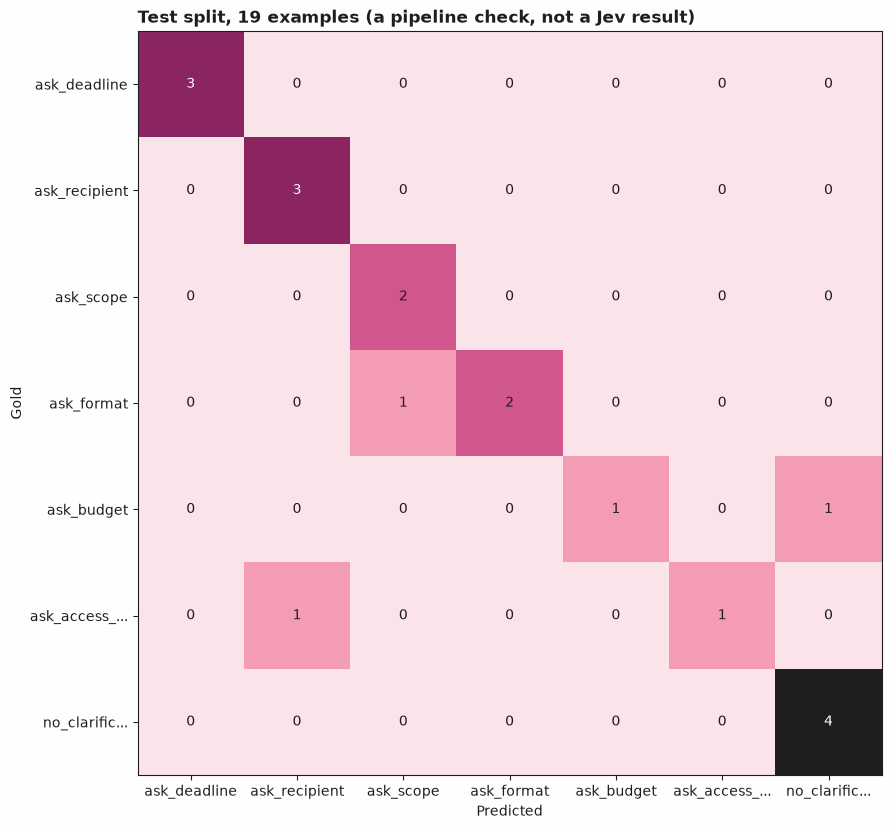

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, test_counts = report(test_examples, test_answers, threshold)
print(f"test, {len(test_examples)} examples, confidence gate {threshold:.4f} frozen{check}")
print(f"accuracy of the selected follow-up: {accuracy(test_gold, test_answers):.4f}{check}")
print(
    f"ask: {test_counts[helpers.ASK]}, review: {test_counts[helpers.REVIEW]}, "
    f"proceed: {test_counts[helpers.PROCEED]} (of {len(test_examples)}){check}"
)

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
print(f"gold (row) by predicted (column), {len(helpers.OPTIONS)} options{check}:")
for row_label, row in zip(matrix.labels, matrix.matrix, strict=True):
    print(f"  {row_label:24s} {list(int(v) for v in row)}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Three of `test`'s nineteen tasks are wrong, in three different ways. "Prepare the Q2 marketing spend breakdown for finance by next Tuesday" (`t09-format-wrong`) is gold `ask_format` (the period is already named, the deliverable's shape is not), but the stored answer names `ask_scope` instead at a confidence of 0.4750, comfortably above the frozen gate (0.3350) -- a real, wrong catalog entry the confidence gate lets straight through, because the gate only protects against *low* confidence, not against being confidently wrong. "Set up a shared doc for collecting interview feedback, ready before Thursday's debrief" (`t15-access-wrong-caught`) is gold `ask_access_level`, and the stored answer names `ask_recipient` instead, but only at a confidence of 0.0900, below the gate, so this one *is* caught, and sent to `review` rather than reported. "Book travel for the three engineers attending the vendor summit in March" (`t12-budget-wrong`) is gold `ask_budget`, but the stored answer names `no_clarification_needed` instead, at a confidence of only 0.1833 -- below the frozen gate, the same side of it as `t15-access-wrong-caught` above. A confidence-only rule would therefore have sent this one to review too; `select_followup` never checks `no_clarification_needed`'s confidence at all, though, so it is delivered as a final "nothing to ask" result anyway. Unlike `t09-format-wrong` (a gate that lets a confident mistake through) and `t15-access-wrong-caught` (a gate that catches a low-confidence one), `t12-budget-wrong`'s mistake is not about what the gate does with a confidence value -- it is that the un-gated branch itself decided something a confidence gate would not have let through. The next section makes that difference concrete.

In [10]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:24s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

val_bin_gold = ["proceed" if g == helpers.NO_CLARIFICATION_NEEDED else "ask" for g in val_gold]
val_bin_pred = [
    "proceed" if a.choice == helpers.NO_CLARIFICATION_NEEDED else "ask" for a in val_answers
]
test_bin_gold = ["proceed" if g == helpers.NO_CLARIFICATION_NEEDED else "ask" for g in test_gold]
test_bin_pred = [
    "proceed" if a.choice == helpers.NO_CLARIFICATION_NEEDED else "ask" for a in test_answers
]
print()
print(
    f"accuracy of the ask-or-proceed decision, validation: "
    f"{accuracy(val_bin_gold, val_bin_pred):.4f}{selection}{check}"
)
print(
    f"accuracy of the ask-or-proceed decision, test: "
    f"{accuracy(test_bin_gold, test_bin_pred):.4f}{check}"
)

ask_deadline             precision 1.000  recall 1.000  f1 1.000  support 3 (a pipeline check, not a Jev result)
ask_recipient            precision 0.750  recall 1.000  f1 0.857  support 3 (a pipeline check, not a Jev result)
ask_scope                precision 0.667  recall 1.000  f1 0.800  support 2 (a pipeline check, not a Jev result)
ask_format               precision 1.000  recall 0.667  f1 0.800  support 3 (a pipeline check, not a Jev result)
ask_budget               precision 1.000  recall 0.500  f1 0.667  support 2 (a pipeline check, not a Jev result)
ask_access_level         precision 1.000  recall 0.500  f1 0.667  support 2 (a pipeline check, not a Jev result)
no_clarification_needed  precision 0.800  recall 1.000  f1 0.889  support 4 (a pipeline check, not a Jev result)

accuracy of the ask-or-proceed decision, validation: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the ask-or-proceed decision, test: 0.9474 (a pipeline che

For each catalog entry, **precision** is the fraction of the rule's raw choices of that option that were actually right, and **recall** is the fraction of that option's real `test` tasks the raw choice found at all; **f1** is their harmonic mean, a single number that is low whenever either one is, and **support** is how many `test` tasks actually carry that gold label, so a recall or precision figure is only as meaningful as its support is large -- `ask_scope`, `ask_budget` and `ask_access_level` each have `support` 2 here, so one wrong task moves a figure by a full half.

`ask_format`'s recall (0.667) is `t09-format-wrong` above, read as `ask_scope` instead; `ask_scope`'s precision (0.667) is that same mistake landing as a false `ask_scope` on top of its own two correct ones. `ask_budget`'s and `ask_access_level`'s recall (0.500 each) are `t12-budget-wrong` and `t15-access-wrong-caught` respectively, one task each out of a `support` of two. `no_clarification_needed`'s precision (0.800) is 4 of the 5 raw choices that named it truly needing no clarification: the fifth is `t12-budget-wrong`, a real `ask_budget` task the rule misreads as needing nothing asked at all.

The **accuracy of the selected follow-up** above scores all seven options against each other; the **accuracy of the ask-or-proceed decision** collapses the six `ask_*` options into one "ask" outcome and asks only the coarser question: did the rule's raw choice agree with the gold label on whether to ask *something* at all, versus proceeding? On `test` this is 0.9474 (18 of 19), higher than the 0.8421 selected-follow-up accuracy, because `t09-format-wrong` and `t15-access-wrong-caught` both name the wrong catalog entry but still correctly decide that *something* should be asked; only `t12-budget-wrong` gets the coarser ask-or-proceed decision itself wrong, by proceeding when a budget question was actually needed.

## What the rule's own outcomes say

The `ask`/`review`/`proceed` counts above come straight from `select_followup`. `jev_cookbook.evaluation.evaluate_selective` is not used here to summarize them: that helper reapplies one confidence gate to every example, but `select_followup` never applies the gate to a `no_clarification_needed` answer, so reapplying it there would score a gate the rule does not have. **Selective prediction** is the general pattern this recipe's rule is one instance of: a system that may decline to answer (here, `review`) instead of always committing to a choice, scored by how much it answers and how often those answers are right. A rule with a review branch beyond the confidence gate needs its selective-prediction numbers computed from the rule's own outcomes, not from a generic helper that assumes the gate is the only branch: `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` is that helper, fed `helpers.outcome_accounting`'s `(accepted, correct)` pair built from what `select_followup` actually decided. **Coverage** is the fraction of tasks the rule actually answered -- `ask` or `proceed`, either one a real result handed back -- rather than held for `review`; among those answered, **accuracy** is the fraction that are right, and **risk** is its complement, `1 - accuracy`, the fraction of answered tasks that are wrong despite the rule having delivered a result for them.

In [11]:
val_gold_by_id = {e.fields["task_id"]: g for e, g in zip(val_examples, val_gold, strict=True)}
val_accepted, val_correct = helpers.outcome_accounting(val_results, val_gold_by_id)
val_summary = evaluate_outcomes(val_accepted, val_correct)
print(
    f"validation: answered {val_summary.n_answered} of {val_summary.n_total} "
    f"(coverage {val_summary.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_summary.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_summary.risk:.4f}{selection}{check}")

test_gold_by_id = {e.fields["task_id"]: g for e, g in zip(test_examples, test_gold, strict=True)}
test_accepted, test_correct = helpers.outcome_accounting(test_results, test_gold_by_id)
test_summary = evaluate_outcomes(test_accepted, test_correct)
print()
print(
    f"test: answered {test_summary.n_answered} of {test_summary.n_total} "
    f"(coverage {test_summary.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_summary.accuracy:.4f}{check}")
print(f"risk among those answered: {test_summary.risk:.4f}{check}")

validation: answered 18 of 19 (coverage 0.9474) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

test: answered 18 of 19 (coverage 0.9474) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8889 (a pipeline check, not a Jev result)
risk among those answered: 0.1111 (a pipeline check, not a Jev result)


`validation`'s risk is 0.0000: the only wrong answer in `validation`, `v08-scope-wrong`, is reviewed rather than answered, so nothing wrong is ever reported there -- that is what choosing the confidence gate on `validation` is supposed to buy, and it does, on this split. `test`'s risk is not zero, at 0.1111: 16 of the 18 answered tasks are right. The two wrong, answered tasks are `t09-format-wrong` (a confident wrong catalog entry the gate let through) and `t12-budget-wrong` (a wrong `no_clarification_needed` the gate was never asked about, at a confidence that sits *below* the gate); `t15-access-wrong-caught`, the third error, is not among them, because it was reviewed rather than answered. A confidence gate chosen to be perfectly accurate on `validation` says nothing about any task this recipe has not seen, which is exactly what `test`'s non-zero risk shows.

## Why this is not the same as reapplying one confidence gate

`t12-budget-wrong`'s stored answer is confidently *low*: `no_clarification_needed` at 0.1833, below the frozen gate. If `select_followup` gated `no_clarification_needed` the same way it gates the six `ask_*` options, this task would be sent to `review`, the same as `t15-access-wrong-caught` above. It does not: `no_clarification_needed` is accepted whatever its confidence, so `t12-budget-wrong` is answered, wrongly. The next cell computes both views of `test` side by side: `evaluate_outcomes`, fed what `select_followup` actually decided, against `evaluate_selective`, which reapplies the frozen gate to every raw `confidence` as if the gate were the rule's only review branch.

In [12]:
test_correct_raw = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence_raw = [a.confidence for a in test_answers]
naive = evaluate_selective(test_correct_raw, test_confidence_raw, threshold)

print(f"test, evaluate_outcomes (what select_followup actually decided){check}:")
print(
    f"  coverage {test_summary.coverage:.4f}, accuracy {test_summary.accuracy:.4f}, "
    f"risk {test_summary.risk:.4f}{check}"
)
print(f"test, evaluate_selective (one confidence gate reapplied to every answer){check}:")
print(
    f"  coverage {naive.coverage:.4f}, accuracy {naive.accuracy:.4f}, risk {naive.risk:.4f}{check}"
)

test, evaluate_outcomes (what select_followup actually decided) (a pipeline check, not a Jev result):
  coverage 0.9474, accuracy 0.8889, risk 0.1111 (a pipeline check, not a Jev result)
test, evaluate_selective (one confidence gate reapplied to every answer) (a pipeline check, not a Jev result):
  coverage 0.8947, accuracy 0.9412, risk 0.0588 (a pipeline check, not a Jev result)


The two disagree. `evaluate_selective` excludes `t12-budget-wrong` from "answered" -- its raw confidence, 0.1833, sits below the gate, the same reason it excludes `t15-access-wrong-caught` -- so it reports a smaller `test` coverage (0.8947) but a smaller `risk` too (0.0588), as if `t12-budget-wrong` had been reviewed. `select_followup` never checked that confidence at all, so it answered `t12-budget-wrong` anyway, wrongly; `evaluate_outcomes` counts that mistake, reporting the larger coverage (0.9474) and the larger `risk` (0.1111) that are actually true of this notebook's rule. `evaluate_selective`'s numbers describe a rule this recipe does not run -- one where `no_clarification_needed` is gated on confidence like every other option; `evaluate_outcomes`, fed `select_followup`'s real decisions, is the one that is true of it.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored tasks (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, four of them wrong on purpose and in different ways (one in `validation` itself, caught by the gate it goes on to define; one in `test` that is wrong and confident through the gate; one in `test` that is wrong but caught by the gate; one in `test` that is wrong and delivered anyway through the un-gated `no_clarification_needed` branch, despite a confidence that a gated rule would have caught), so every number above describes this fixture set and not a model.

In [13]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard task to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `select_followup` sends it.
- Change the confidence gate's target in the "Python's part" cell (`target_accuracy=1.0` to something looser, such as `0.9`) and see how coverage and the review count trade off: loosening it enough to tolerate `v08-scope-wrong` drops the frozen gate back to 0.3000 and changes which `validation` tasks are reviewed.
- Neighbouring recipes: [`04-support-ticket-routing`](../04-support-ticket-routing/) and [`08-faq-selection`](../08-faq-selection/), which build on a `Choice` over a fixed option set with its own fallback outcome, the second over a candidate list much like this recipe's catalog.